# Statistical Analysis of the Dataset: Relationship between Time and Score

## Data
- **Data set ID:** 272
- **Data set:** Exam

## Group

- **Name:** Gabriel Nørrelykke K. Kihara  
  **Email:** stud-gnk@ruc.dk  
  **Student Number:** 80944

- **Name:** Cabdi Raxman Mohamed Aadan  
  **Email:** stud-crmsh@ruc.dk  
  **Student Number:** 80909

- **Name:** Jiaxu Yang  
  **Email:** stud-jiaxu@ruc.dk  
  **Student Number:** 80886

- **Name:** Divine Agbogah  
  **Email:** stud-ddaw@ruc.dk  
  **Student Number:** 82488

- **Name:** Sabin Ghimire  
  **Email:** stud-sabin@ruc.dk  
  **Student Number:** 80898


## Introduction

In this study, we analyze a dataset that includes two variables: **Time** and **Score**. The objective is to perform a comprehensive statistical analysis to understand the distribution of each variable, the relationship between them, and determine if they follow specific statistical patterns such as the normal (Gaussian) distribution or binomial distribution. Additionally, we will explore the existence of trends, calculate various statistical measures such as mean, standard deviation, interquartile range (IQR), and more.

## Research Question

*Do students who stay longer in the exam get higher scores on the exam?*

In [326]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm

data = pd.read_csv("exam.csv")

data

,Score,Time
0,49,2860
1,49,2063
2,70,2013
3,55,2000
4,52,1420
...,...,...
129,42,1908
130,61,1853
131,69,1302
132,42,2161


In [279]:
data.describe()

,Score,Time
count,134.000000,134.000000
mean,54.529851,1823.798507
std,9.813824,464.135283
min,28.000000,1068.000000
25%,48.250000,1512.250000
50%,55.000000,1756.000000
75%,62.000000,2013.000000
max,73.000000,3813.000000


***
Based on the data provided from the test, we observe that the sample consists of only 134 individuals, which is insufficient for adequately representing the population.

The description of the data is unknown, and we cannot fully confirm the sampling method used. However, we can reasonably assume it is random, as the data appears widely dispersed, with several measurements displaying outliers. These outliers could be attributed to random variation, given that factors such as individual experiences, education, mental state, and prior exposure may influence both the scores and the time required to complete the test.

To enhance the reliability of the findings, a larger sample size is recommended. Additionally, collecting supplementary information, such as age, gender, profession, and education level, would improve the representativeness of the sample, allowing for more accurate generalizations about the population.
***

In [281]:
score_IQR = data['Score'].quantile(0.75) - data['Score'].quantile(0.25)
time_IQR = data['Time'].quantile(0.75) - data['Time'].quantile(0.25)
print(f"IQR of Score: {score_IQR}")
print(f"IQR of Time: {time_IQR}")

IQR of Score: 13.75
IQR of Time: 500.75


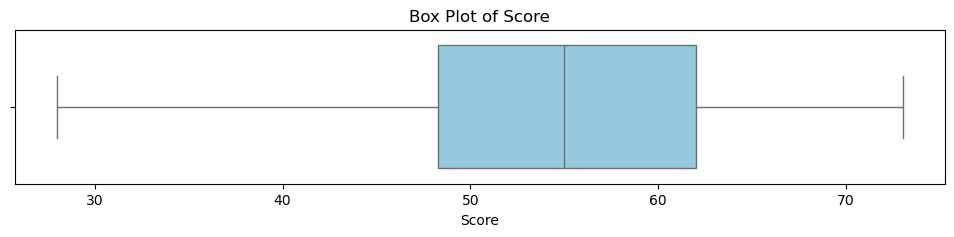

In [282]:
plt.figure(figsize=(12, 2))
sns.boxplot(x=data['Score'], color='skyblue')
plt.title('Box Plot of Score')
plt.xlabel('Score')
plt.show()

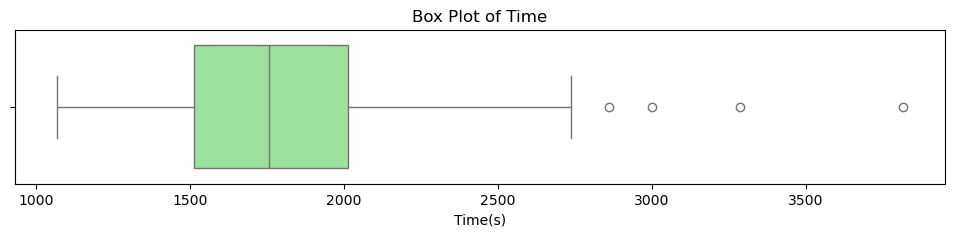

In [283]:
plt.figure(figsize=(12, 2))
sns.boxplot(x=data['Time'], color='lightgreen')
plt.title('Box Plot of Time')
plt.xlabel('Time(s)')
plt.show()

***
We can see that in the last graph several points deviate quite a bit from the normal, which later we will observe that this will affect their normal distribution at the extremes.
***

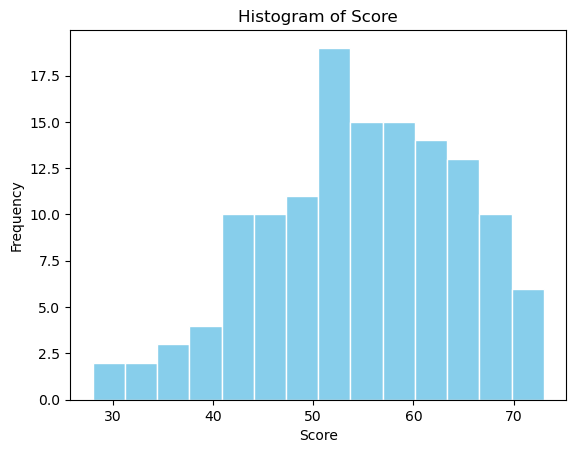

In [285]:
plt.hist(data['Score'], bins=14, color='skyblue', edgecolor='white')
plt.title('Histogram of Score')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

***
**Note:** Because the seaborn library gives us more tools and we consider that it looks visually cleaner, from now on we will use seaborn instead of matplotlib, although it should be noted that both would be useful for the following analysis.
***

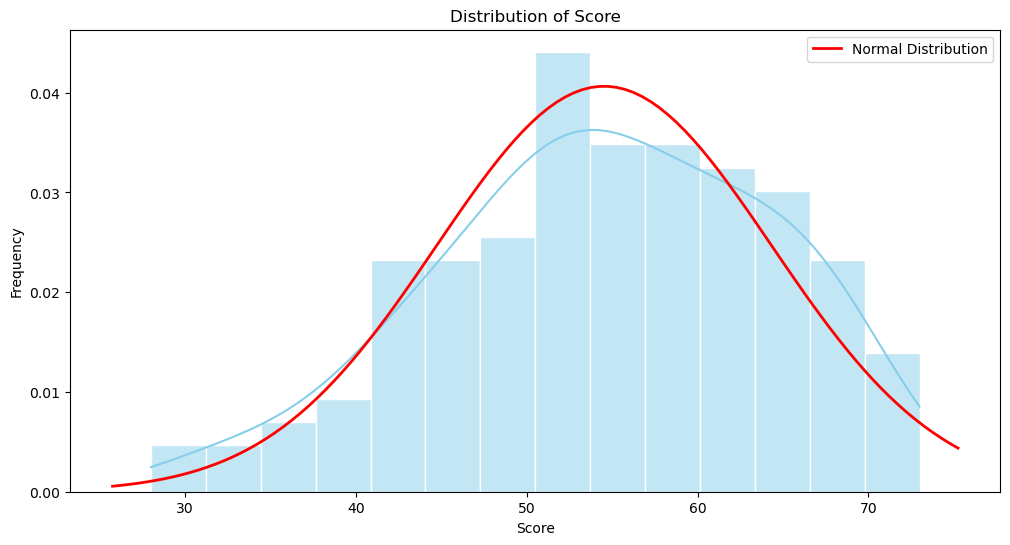

In [346]:
mean_score = data['Score'].mean()
std_score = data['Score'].std()

plt.figure(figsize=(12, 6))
sns.histplot(data['Score'], bins=14, kde=True, color='skyblue', edgecolor='white', stat='density')
xmin_score, xmax_score = plt.xlim()
x_score = np.linspace(xmin_score, xmax_score, 100)
p_score = norm.pdf(x, mean_score, std_score)
plt.plot(x_score, p_score, 'r', linewidth=2, label='Normal Distribution')
plt.title('Distribution of Score')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.legend()

plt.show()

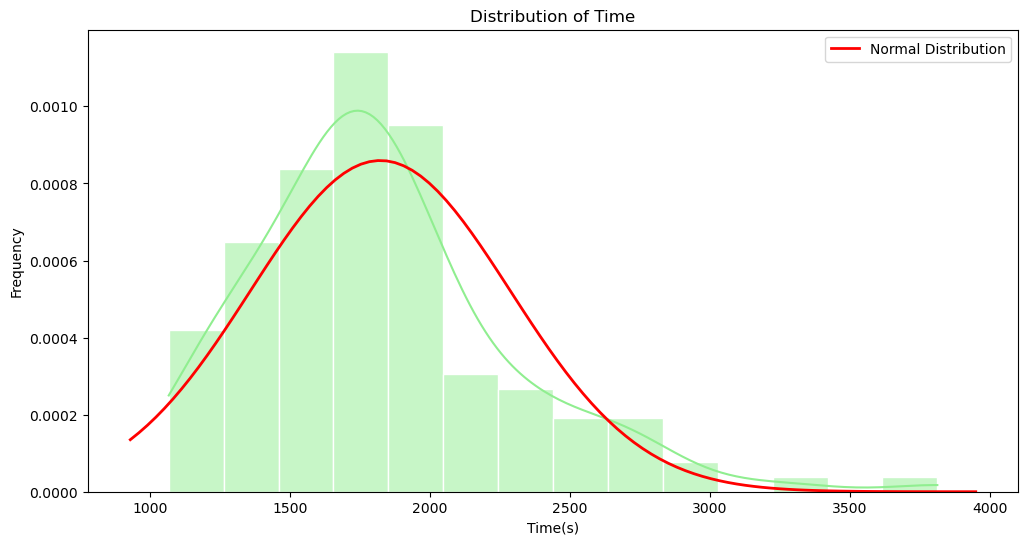

In [340]:
mean_time = data['Time'].mean()
std_time = data['Time'].std()

plt.figure(figsize=(12, 6))
sns.histplot(data['Time'], bins=14, kde=True, color='lightgreen', edgecolor='white', stat="density")
xmin_time, xmax_time = plt.xlim()
x_time = np.linspace(xmin_time, xmax_time, 100)
p_time = norm.pdf(x_time, mean_time, std_time)
plt.plot(x_time, p_time, 'r', linewidth=2, label='Normal Distribution')
plt.title('Distribution of Time')
plt.xlabel('Time(s)')
plt.ylabel('Frequency')
plt.legend()

plt.show()

***
Both score and time seem to follow a normal distribution, we will use the Q-Q plot to confirm this hypothesis.
***

<Figure size 1200x600 with 0 Axes>

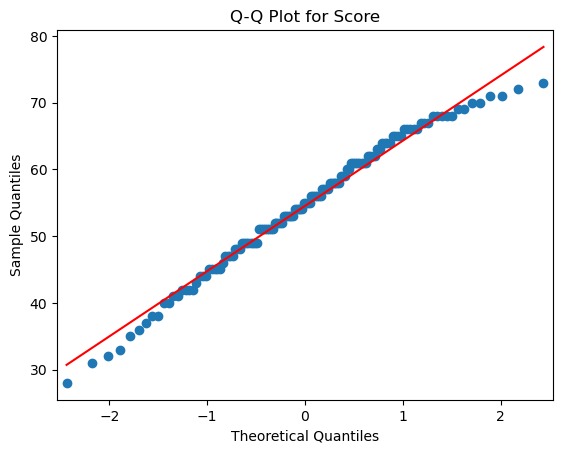

In [290]:
plt.figure(figsize=(12, 6))
sm.qqplot(data['Score'], line='s')
plt.title('Q-Q Plot for Score')
plt.show()

***
We can observe that the Q-Q plot tends to align with a straight line, indicating that the scores follow a normal distribution.
***

<Figure size 1200x600 with 0 Axes>

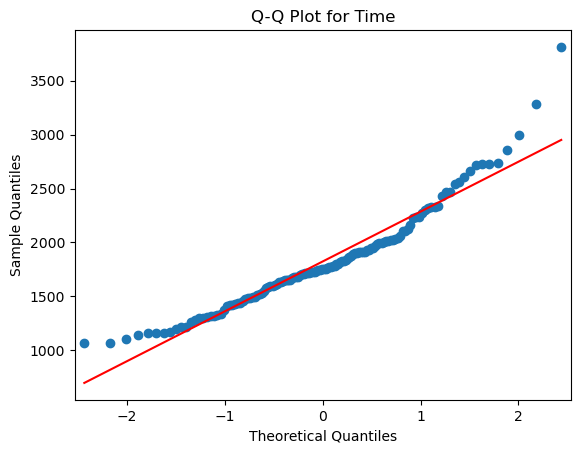

In [292]:
plt.figure(figsize=(12, 6))
sm.qqplot(data['Time'], line='s')
plt.title('Q-Q Plot for Time')
plt.show()

***
While the Q-Q plot appears to be linear across most of the domain, it deviates significantly at the extremes. This deviation could be caused by a small sample size or by the fact that the frequency of extreme values is slightly higher than that of a normal distribution. However, we can still reasonably conclude that the data tends to follow a normal distribution.
***

In [294]:
confidence_level = 0.95
alpha = 1 - confidence_level

# For Timeeeee
n_time = len(data['Time'])
df_time = n_time - 1  
mean_time = data['Time'].mean() 
std_time = data['Time'].std(ddof=1)
se_time = std_time / np.sqrt(n_time) 

t_critical_time = stats.t.ppf(1 - alpha/2, df_time)

margin_of_error_time = t_critical_time * se_time

ci_time_lower = mean_time - margin_of_error_time
ci_time_upper = mean_time + margin_of_error_time

print(f"95% Confidence Interval for Time Mean: ({ci_time_lower:.2f}, {ci_time_upper:.2f})")

#For Scoreeeee
n_score = len(data['Score'])
df_score = n_score - 1
mean_score = data['Score'].mean()
std_score = data['Score'].std(ddof=1)
se_score = std_score / np.sqrt(n_score)

t_critical_score = stats.t.ppf(1 - alpha/2, df_score)
margin_of_error_score = t_critical_score * se_score

ci_score_lower = mean_score - margin_of_error_score
ci_score_upper = mean_score + margin_of_error_score

print(f"95% Confidence Interval for Score Mean: ({ci_score_lower:.2f}, {ci_score_upper:.2f})")

95% Confidence Interval for Time Mean: (1744.49, 1903.11)
95% Confidence Interval for Score Mean: (52.85, 56.21)


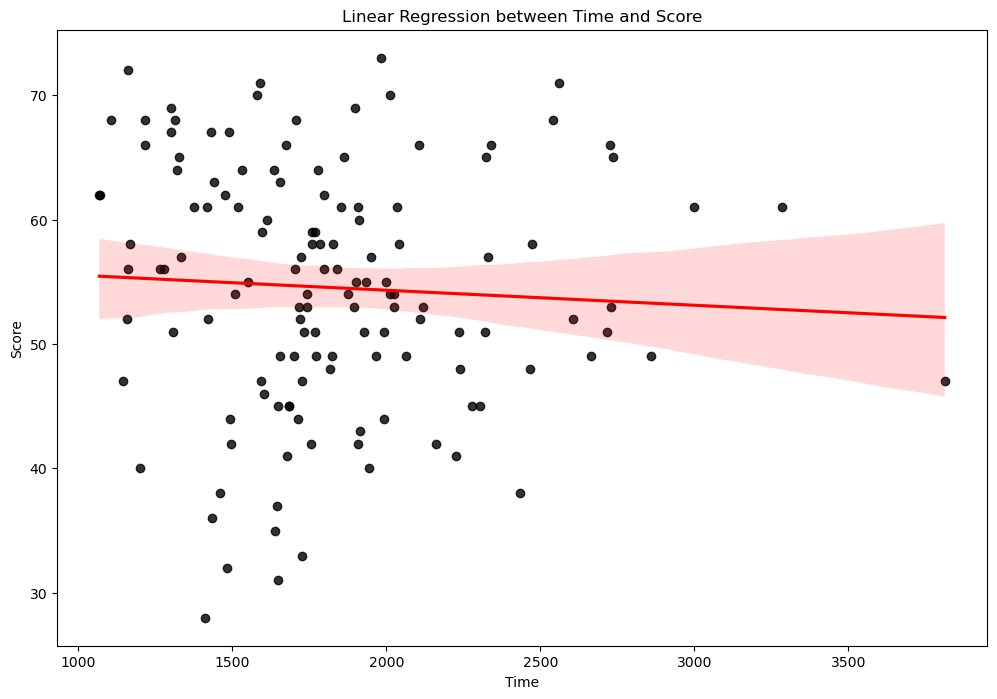

In [295]:
plt.figure(figsize=(12, 8))
sns.regplot(x='Time', y='Score', data=data, color='black', line_kws={'color': 'red'})
plt.title('Linear Regression between Time and Score')
plt.xlabel('Time')
plt.ylabel('Score')
plt.show() # Soy yo o los puntos parece formar la silueata de España? jaja

In [296]:
slope, intercept, r_value, p_value, std_err = stats.linregress(data['Time'], data['Score'])
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"R-value (Correlation coefficient): {r_value}")
print(f"P-value: {p_value}")
print(f"Standard Error: {std_err}")
print(f"Coefficient of Determination (R^2): {r_value**2}")

Slope: -0.001208146745587145
Intercept: 56.733266977666396
R-value (Correlation coefficient): -0.057138130662466355
P-value: 0.5119778500979182
Standard Error: 0.0018373699117238632
Coefficient of Determination (R^2): 0.003264765975601078


***
The slope of the line is practically 0, so both variables are independent of each other and there is no correlation, therefore the correlation of person and spearman will be approximately 0.
***

In [298]:
# Extra
corr_pearson, _ = stats.pearsonr(data['Time'], data['Score'])
corr_spearman, _ = stats.spearmanr(data['Time'], data['Score'])
print(f"Pearson Correlation between Time and Score: {corr_pearson}")
print(f"Spearman Correlation between Time and Score: {corr_spearman}")

Pearson Correlation between Time and Score: -0.057138130662466334
Spearman Correlation between Time and Score: -0.10951483332175686


***
Indeed, as we deduced in the previous section, the correlation of both is practically 0, confirming the previous hypothesis and observations.
***

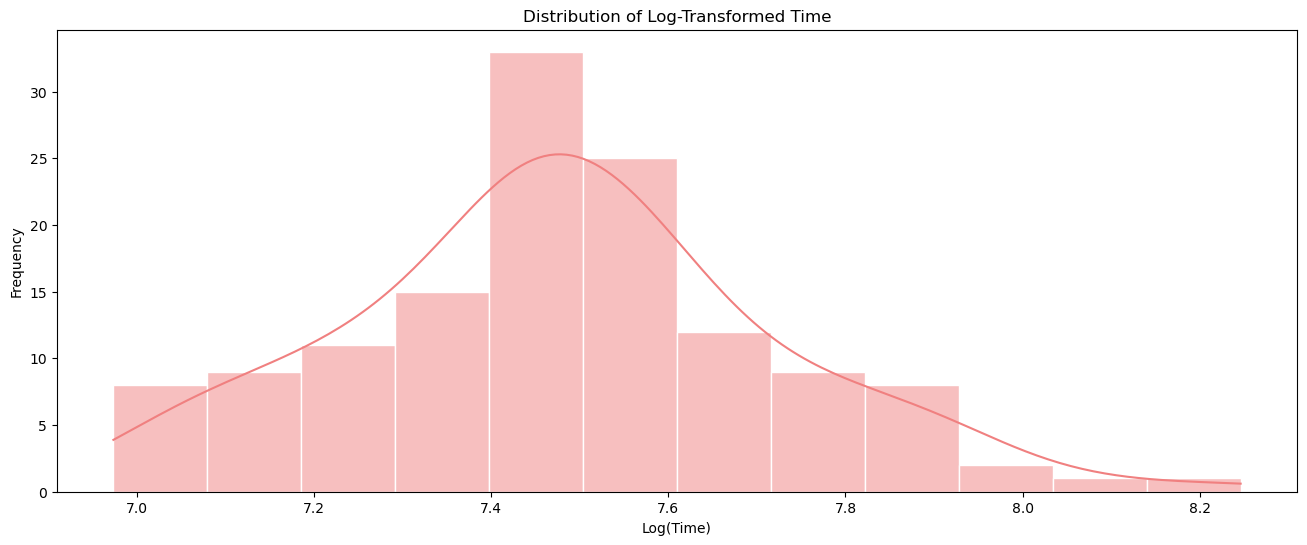

In [300]:
data['Log_Time'] = np.log(data['Time'])

plt.figure(figsize=(16, 6))
sns.histplot(data['Log_Time'], bins=12, kde=True, color='lightcoral', edgecolor='white')
plt.title('Distribution of Log-Transformed Time')
plt.xlabel('Log(Time)')
plt.ylabel('Frequency')
plt.show()

***
When time is log-transformed, it appears to follow a normal distribution, and we can confirm this with a Q-Q plot.
***

<Figure size 1200x600 with 0 Axes>

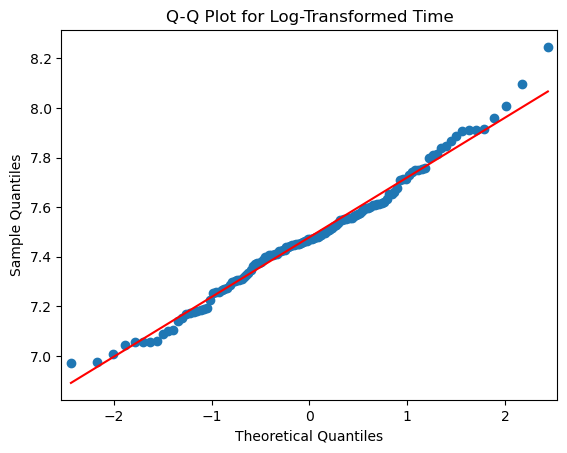

In [302]:
plt.figure(figsize=(12, 6))
sm.qqplot(data['Log_Time'], line='s')
plt.title('Q-Q Plot for Log-Transformed Time')
plt.show()

***
Evidently it is observed that it has a tendency to a normal distribution when time is managed logarithmically, so it is logarithmically normally distributed (there are many studies that claim that the human perception of time is logarithmic, so this could be related but this will require much additional research, for now we can not make any conclusions about this).
***

In [304]:
slope_log, intercept_log, r_value_log, p_value_log, std_err_log = stats.linregress(data['Log_Time'], data['Score'])
print(f"Slope: {slope_log}")
print(f"Intercept: {intercept_log}")
print(f"R-value: {r_value_log}")
print(f"P-value: {p_value_log}")
print(f"Coefficient of Determination (R^2): {r_value_log**2}")

Slope: -3.3792423085929117
Intercept: 79.80301994412778
R-value: -0.0833448831759795
P-value: 0.33835780259619785
Coefficient of Determination (R^2): 0.006946369551617672


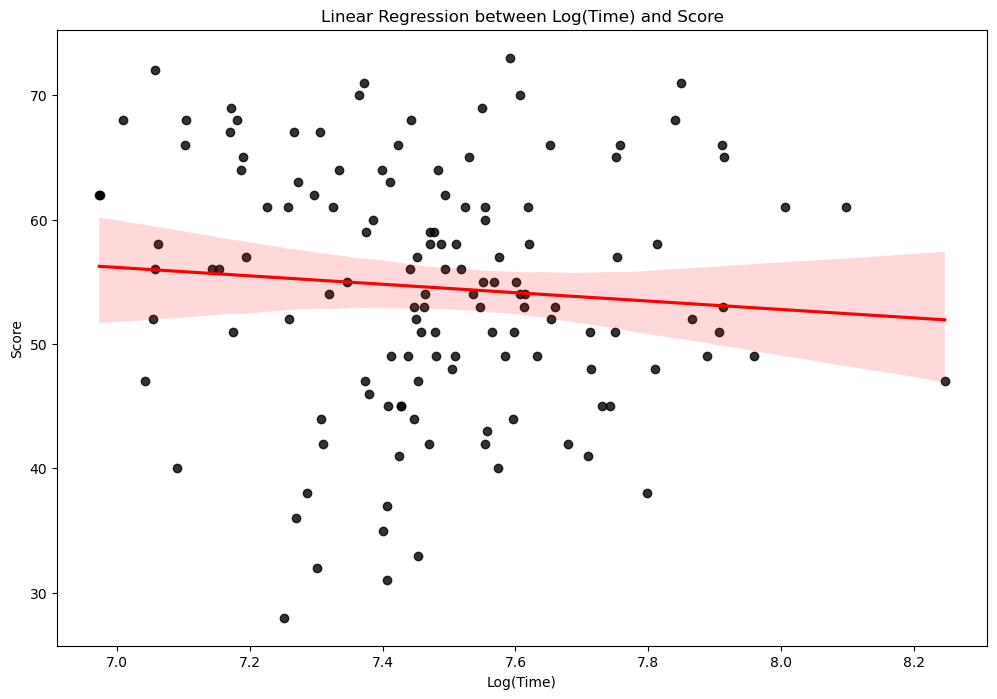

In [305]:
plt.figure(figsize=(12, 8))
sns.regplot(x='Log_Time', y='Score', data=data, color='black', line_kws={'color': 'red'})
plt.title('Linear Regression between Log(Time) and Score')
plt.xlabel('Log(Time)')
plt.ylabel('Score')
plt.show()

***
It is obvious that logarithmic time still has no correlation with the score.
***

## Conclusions

The score and time follow a normal distribution, although the logarithmic time seems to have even more tendency to a normal distribution, additionally we observed that time and score are independent variables therefore the increase of one variable does not imply that the probabilities of the other also increases. We were also able to see other data such as mean and standard deviation which are in the upper sections. Since we lack information about the sample and it is a singular observation we ccan only hypothesise as mentioned before that time spent and scores are indeendent variables.